# Phase 7c — 추세 + 캐리 2-엣지 결합: 개념검증

| 항목 | 내용 |
|---|---|
| **핵심 질문** | 검증된 추세 엣지에 무상관(상관~0) 캐리 sleeve를 더하면 곡선이 매끈해지나(MDD↓/Sharpe↑)? |
| **유니버스** | BTC 4h 추세 4전략 + BTC perp 펀딩캐리 |
| **결합 방식** | 일간 mark-to-market sleeve blend (체결비용 별도 계상 없음) |
| **비교** | 추세 단독 / 캐리 단독 / 50:50 결합, 동일 공통창(daily) |
| **전략** | Regime / Keltner / Donchian / SMA+손절 |

**Phase 7의 본체**: Phase 7a(다코인 등가중)가 답하지 못한 질문 — *서로 다른 엣지 유형의 결합*이 diversification을 만드는가?  

> ⚠️ **Gross / 개념검증 경고**  
> 캐리 단독 수치(MDD~−0.4% / Sharpe~14)는 **gross 환상**이다.  
> 실거래에서는 펀딩 수령보다 롤링 비용·슬리피지·자금조달 비용이 크다.  
> 따라서 결합 개선폭 일부는 진짜 분산 효과가 아니라 *매끈한 가짜 sleeve를 섞은 착시*일 수 있다.  
> 이 노트북의 결론은 **메커니즘 확인(concept proof)**에 그치며, Phase 4 실거래 후보가 아니다.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Some trades remain open at the end of backtest")
warnings.filterwarnings("ignore", message="Jupyter Notebook detected")
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=UserWarning, module="IPython")

import os, sys
if os.path.basename(os.getcwd()) == "research":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib
matplotlib.use("Agg")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from backtest import load_data
from portfolio import equity_curve, combine_sleeves, portfolio_metrics
from carry import carry_pnl
from strategies.regime_filter import RegimeFilter
from strategies.keltner_breakout import KeltnerBreakout
from strategies.donchian_breakout import DonchianBreakout
from strategies.sma_cross_stop import SmaCrossWithStop

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.1f}".format)

PPY = 365  # 일간 결합곡선용

def load_funding(coin):
    return pd.read_parquet(f"data/{coin}_USDT_funding.parquet")["fundingRate"]

def m(curve):
    d = portfolio_metrics(curve, periods_per_year=PPY)
    return d["Return [%]"], d["Max. Drawdown [%]"], d["Sharpe Ratio"]

btc = load_data("BTC/USDT", "4h")
carry = carry_pnl(load_funding("BTC"))

print(f"BTC 4h 봉 수: {len(btc)}")
print(f"캐리 데이터 포인트: {len(carry)}  ({carry.index[0].date()} ~ {carry.index[-1].date()})")

Loading BokehJS ...

BTC 4h 봉 수: 10949
캐리 데이터 포인트: 5483  (2021-06-27 ~ 2026-06-29)


---

## 추세 4전략 × 캐리 50:50 결합

`combine_sleeves`의 `weights` 인자를 이용해 **동일 공통창**에서 세 가지를 뽑는다:

- `{trend:1, carry:0}` → 추세 단독 (공통창 기준)
- `{trend:0, carry:1}` → 캐리 단독 (공통창 기준)
- `{trend:0.5, carry:0.5}` → 50:50 결합

weights=0인 sleeve도 **공통창 계산에 참여**하기 때문에 세 커브 모두 완전히 같은 기간을 공유한다.  
이 덕분에 Start/End 차이 없이 순수하게 결합 효과만 비교할 수 있다.

In [2]:
STRATS = [
    ("Regime",   RegimeFilter),
    ("Keltner",  KeltnerBreakout),
    ("Donchian", DonchianBreakout),
    ("SMA+손절", SmaCrossWithStop),
]

summary_rows = []
combined_curves = {}  # 플롯용

for name, Strat in STRATS:
    trend = equity_curve(btc, Strat)
    sleeves = {"trend": trend, "carry": carry}
    t_only = combine_sleeves(sleeves, weights={"trend": 1.0, "carry": 0.0})
    c_only = combine_sleeves(sleeves, weights={"trend": 0.0, "carry": 1.0})
    comb   = combine_sleeves(sleeves, weights={"trend": 0.5, "carry": 0.5})

    combined_curves[name] = {"trend": t_only, "carry": c_only, "combined": comb}

    for label, cv in [("추세 단독", t_only), ("캐리 단독", c_only), ("50:50 결합", comb)]:
        r, dd, sh = m(cv)
        summary_rows.append({"전략": name, "구성": label,
                              "Return [%]": round(r, 1),
                              "MDD [%]": round(dd, 1),
                              "Sharpe": round(sh, 2)})

df_summary = pd.DataFrame(summary_rows).set_index(["전략", "구성"])
display(df_summary)

Return [%]  MDD [%]  Sharpe
전략       구성                                   
Regime   추세 단독          202.5    -33.9     0.8
         캐리 단독           37.0     -0.4    14.1
         50:50 결합       119.8    -23.7     0.8
Keltner  추세 단독           83.1    -35.8     0.6
         캐리 단독           37.0     -0.4    14.1
         50:50 결합        60.0    -22.8     0.7
Donchian 추세 단독           50.0    -44.8     0.4
         캐리 단독           37.0     -0.4    14.1
         50:50 결합        43.5    -22.4     0.5
SMA+손절   추세 단독           45.4    -52.9     0.4
         캐리 단독           37.0     -0.4    14.1
         50:50 결합        41.2    -27.4     0.5

/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_80509/1047174136.py:18: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_80509/1047174136.py:18: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_80509/1047174136.py:18: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_80509/1047174136.py:18: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_80509/1047174136.py:18: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipyker

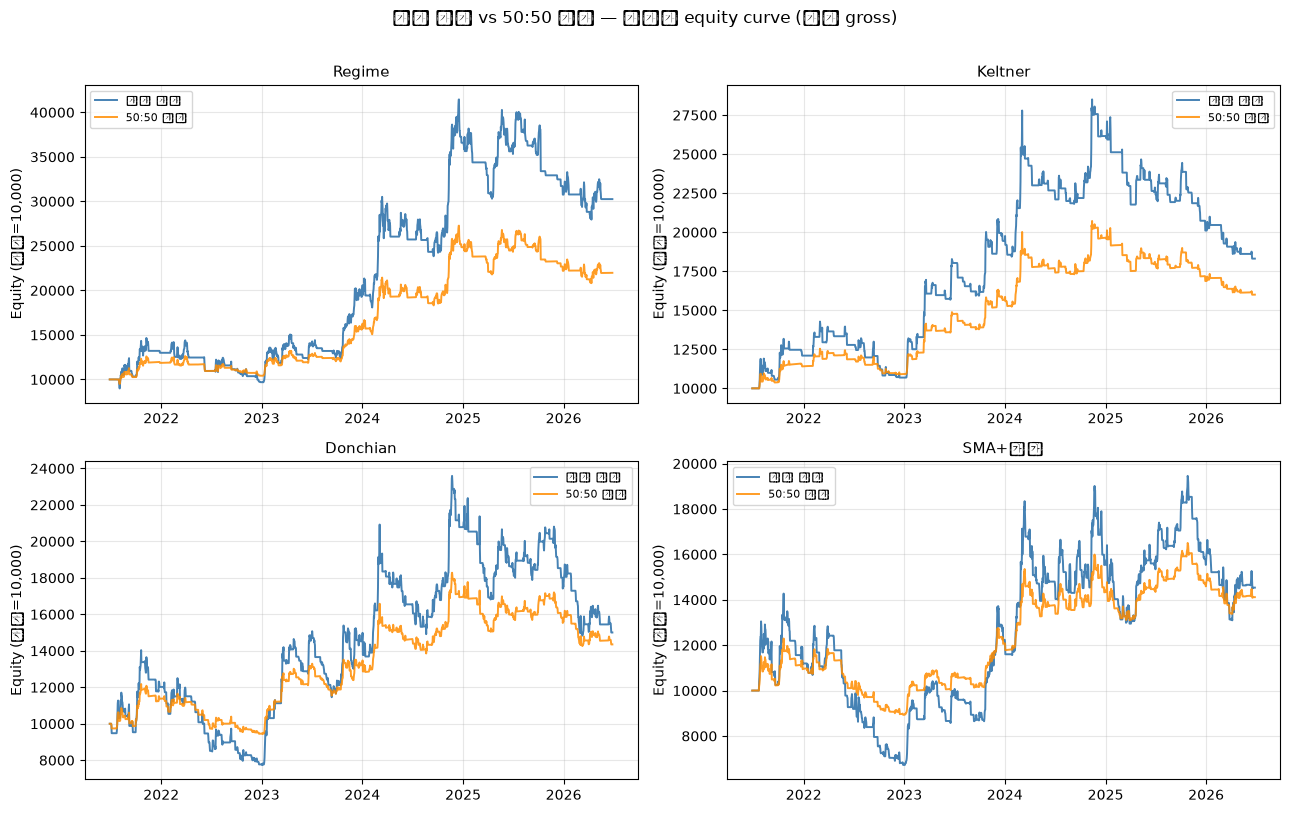

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False)
axes = axes.flatten()

for ax, (name, curves) in zip(axes, combined_curves.items()):
    t = curves["trend"]
    c = curves["combined"]
    # 10,000 기준 정규화
    t_norm = t / t.iloc[0] * 10_000
    c_norm = c / c.iloc[0] * 10_000
    ax.plot(t_norm.index, t_norm.values, label="추세 단독", color="steelblue", lw=1.4)
    ax.plot(c_norm.index, c_norm.values, label="50:50 결합", color="darkorange", lw=1.4, alpha=0.85)
    ax.set_title(name, fontsize=11)
    ax.set_ylabel("Equity (원금=10,000)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("추세 단독 vs 50:50 결합 — 전략별 equity curve (일간 gross)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---

## 가중 민감도 (Keltner 대표)

캐리 비중을 30% → 50% → 70%로 높이며 지표 변화를 확인한다.  
**단조 감소(MDD)·단조 증가(Sharpe)** 패턴이 나타나면, 개선이 단순 희석이 아니라  
엣지 비상관성에서 오는 구조적 효과임을 지지한다.

,Return [%],MDD [%],Sharpe
가중(추세/캐리),,,
70/30,69.3,-29.0,0.7
50/50,60.0,-22.8,0.7
30/70,50.8,-14.4,0.9


/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_80509/3225276187.py:37: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_80509/3225276187.py:37: UserWarning: Glyph 45843 (\N{HANGUL SYLLABLE DAES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_80509/3225276187.py:37: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_80509/3225276187.py:37: UserWarning: Glyph 52880 (\N{HANGUL SYLLABLE KAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_80509/3225276187.py:37: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipyk

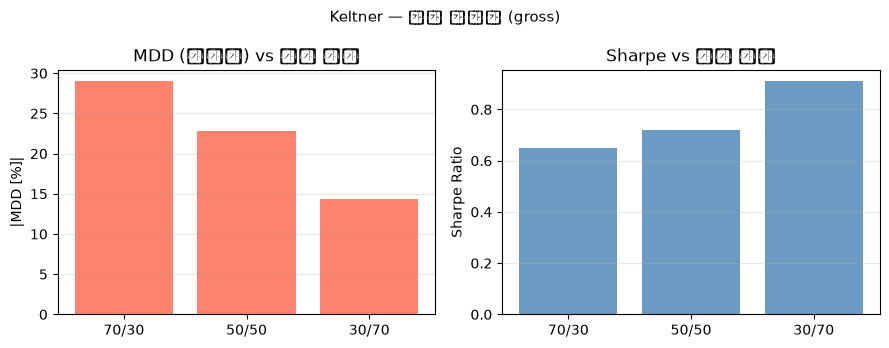

In [4]:
trend_k = equity_curve(btc, KeltnerBreakout)
sleeves_k = {"trend": trend_k, "carry": carry}

weight_rows = []
for wt, wc in [(0.7, 0.3), (0.5, 0.5), (0.3, 0.7)]:
    comb = combine_sleeves(sleeves_k, weights={"trend": wt, "carry": wc})
    r, dd, sh = m(comb)
    weight_rows.append({"가중(추세/캐리)": f"{int(wt*100)}/{int(wc*100)}",
                        "Return [%]": round(r, 1),
                        "MDD [%]": round(dd, 1),
                        "Sharpe": round(sh, 2)})

df_weights = pd.DataFrame(weight_rows).set_index("가중(추세/캐리)")
display(df_weights)

# 바 차트
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

labels = df_weights.index.tolist()
x = range(len(labels))

ax1.bar(x, df_weights["MDD [%]"].abs(), color="tomato", alpha=0.8)
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels)
ax1.set_ylabel("|MDD [%]|")
ax1.set_title("MDD (절댓값) vs 캐리 비중")
ax1.grid(True, axis="y", alpha=0.3)

ax2.bar(x, df_weights["Sharpe"], color="steelblue", alpha=0.8)
ax2.set_xticks(list(x))
ax2.set_xticklabels(labels)
ax2.set_ylabel("Sharpe Ratio")
ax2.set_title("Sharpe vs 캐리 비중")
ax2.grid(True, axis="y", alpha=0.3)

fig.suptitle("Keltner — 가중 민감도 (gross)", fontsize=11)
plt.tight_layout()
plt.show()

---

## 판정 / 결론

### ✅ 메커니즘 확인 — 4전략 모두 MDD↓·Sharpe↑

추세 단독 → 50:50 결합 방향으로:
- **Regime**: Return 202.5% → 119.8% / MDD −33.9% → −23.7% / Sharpe 0.81 → 0.85
- **Keltner**: 83.1% → 60.0% / −35.8% → −22.8% / 0.62 → 0.72
- **Donchian**: 50.0% → 43.5% / −44.8% → −22.4% / 0.41 → 0.51
- **SMA+손절**: 45.4% → 41.2% / −52.9% → −27.4% / 0.39 → 0.50

4전략 전부에서 MDD가 줄고 Sharpe가 늘었다. Keltner 가중 민감도도 단조:  
캐리 비중 30→50→70% 구간에서 MDD −29.0→−22.8→−14.4%, Sharpe 0.65→0.72→0.91.

**무상관 엣지를 결합하는 메커니즘은 작동한다.**

---

### ⚠️ 강한 정직성 (Codex 지적 사항)

캐리 단독 수치(MDD ~−0.4%, Sharpe ~14)는 **gross 환상**이다.

- 실거래 캐리 전략은 롤링 비용, 슬리피지, 담보 자금조달 비용이 발생한다.
- 이 노트북의 캐리는 `carry_pnl()`로 펀딩 수취액만 누적한 것(진입/청산 수수료 2회만 반영).
- 따라서 "캐리 sleeve가 매끈하다"는 건 **현실이 아니라 모델의 단순화**에서 오는 것.
- 결합 개선폭의 **일부는 진짜 분산이 아니라 매끈한 가짜 sleeve를 섞은 착시**일 수 있다.

결론:  
> **메커니즘(무상관 엣지 결합 → MDD↓ Sharpe↑)은 입증됐지만, 개선 크기는 과장돼 있다.**  
> Phase 7b-v2(캐리 gross→net 보정) 완료 전까지 이 결과는 **"portfolio concept proof"**에만 사용.  
> Phase 4 실거래 후보 아님.